# Initial Time Series Modelling 
In this notebook I focus on building my initial times series forecasting model, using only time series features such as:
- Month
- Quarter
- Year
- Lagged features based on the median price.

This approach was influenced by the tutorial: 
["Time Series Forecasting with Machine Learning"](https://www.kaggle.com/code/robikscube/time-series-forecasting-with-machine-learning-yt/input) by Rob Mulla (Robikscube)
In which he creates a time series prediction model using XGBoost, with the use of temporal features to predict power usage.

This model has allowed me to become familiar with time series modelling, as well as allowing me to see how well the models predictive power can be with just temporal features. 
While preparing this model I have opted to only use England data as a starting point to simplify the model building process, before scaling to regional and local authority level.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error, r2_score
import joblib

## Loading In and Preparing Median House Price Data 

In [2]:
#Loading in dataset
median_df = pd.read_csv('processed/model_data.csv')
median_df['Date'] = pd.to_datetime(median_df['Date'])

median_df.head()

,Date,region,regionCode,LAcode,LA,median,average,hpi,change,base,...,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,quarter,month,year
0,1995-12-01,East Midlands,12000004,4,ALL,48882.446000,43957.0,18.7,1.5,6.63,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,12,1995
1,1996-01-01,East Midlands,12000004,4,ALL,48915.630857,42965.0,18.3,-2.3,6.38,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1996
2,1996-02-01,East Midlands,12000004,4,ALL,48948.815714,42856.0,18.2,-0.3,6.13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2,1996
3,1996-03-01,East Midlands,12000004,4,ALL,48982.000571,43515.0,18.5,1.5,6.13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3,1996
4,1996-04-01,East Midlands,12000004,4,ALL,49046.851143,44010.0,18.7,1.1,5.94,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,4,1996


In [3]:
#Convert date column into date time object
median_df['Date'] = pd.to_datetime(median_df['Date'])
#Setting date column as index
median_df = median_df.set_index('Date')

In [4]:
median_df

,region,regionCode,LAcode,LA,median,average,hpi,change,base,5year,...,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,quarter,month,year
Date,,,,,,,,,,,,,,,,,,,,,
1995-12-01,East Midlands,12000004,4,ALL,48882.446000,43957.0,18.7,1.5,6.63,8.14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,12,1995
1996-01-01,East Midlands,12000004,4,ALL,48915.630857,42965.0,18.3,-2.3,6.38,8.13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1996
1996-02-01,East Midlands,12000004,4,ALL,48948.815714,42856.0,18.2,-0.3,6.13,7.87,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2,1996
1996-03-01,East Midlands,12000004,4,ALL,48982.000571,43515.0,18.5,1.5,6.13,7.66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3,1996
1996-04-01,East Midlands,12000004,4,ALL,49046.851143,44010.0,18.7,1.1,5.94,7.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,4,1996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-11-01,Yorkshire and The Humber,12000003,6000014,York,315085.760000,194000.0,101.2,-0.7,5.25,5.02,...,310768.91,310493.43,310217.96,309263.02,308308.07,307353.13,305956.00,4,11,2023
2023-12-01,Yorkshire and The Humber,12000003,6000014,York,316014.580000,193000.0,100.5,-0.7,5.25,4.89,...,311044.38,310768.91,310493.43,310217.96,309263.02,308308.07,307353.13,4,12,2023
2024-01-01,Yorkshire and The Humber,12000003,6000014,York,317287.120000,192000.0,100.0,-0.5,5.25,4.68,...,311772.30,311044.38,310768.91,310493.43,310217.96,309263.02,308308.07,1,1,2024


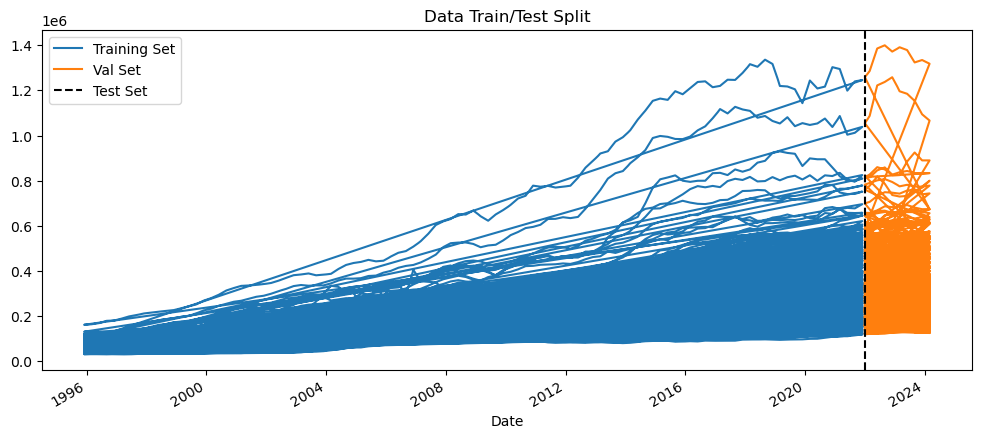

In [5]:
#Splitting data set
#We will be training models on data before 2022
train = median_df.loc[median_df.index < '2022-01-01']
test = median_df.loc[median_df.index >= '2022-01-01']

#Visualising the data split
fig, ax = plt.subplots(figsize=(12, 5))

train['median'].plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test['median'].plot(ax=ax, label='Test Set')

ax.axvline('2022-01-01', color='black', ls='--')
ax.legend(['Training Set', 'Val Set','Test Set'])
plt.show()

In [6]:
numeric_data = median_df.select_dtypes(include=['number']).drop(columns=['regionCode'])
numeric_data = numeric_data.dropna()

TARGET = 'median'
FEATURES = [col for col in numeric_data.columns if col != TARGET]


X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

## Training XGBoost Model with Time Features

In [7]:
model = xgb.XGBRegressor(base_score=0.5, booster='gbtree',    
                       n_estimators=1000,
                       objective='reg:squarederror',
                       max_depth=3,
                       learning_rate=0.01)
model.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)

[0]	validation_0-rmse:218621.08131	validation_1-rmse:370091.87253
[100]	validation_0-rmse:81563.67969	validation_1-rmse:140789.14273
[200]	validation_0-rmse:31603.46300	validation_1-rmse:58730.12003
[300]	validation_0-rmse:14228.38905	validation_1-rmse:33089.35112
[400]	validation_0-rmse:8826.69271	validation_1-rmse:26391.27668
[500]	validation_0-rmse:7215.91834	validation_1-rmse:25014.86180
[600]	validation_0-rmse:6432.96356	validation_1-rmse:24666.79817
[700]	validation_0-rmse:5606.33366	validation_1-rmse:24348.95687
[800]	validation_0-rmse:5097.35629	validation_1-rmse:24198.83330
[900]	validation_0-rmse:4853.89826	validation_1-rmse:24393.66612
[999]	validation_0-rmse:4626.00577	validation_1-rmse:24374.18599


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

## Plotting Predictions for XGBoost with Times Series Features

In [8]:
y_pred = model.predict(X_test)

#Model evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f'XGBoost RMSE: £{rmse:,.2f}')
print(f"XGBoost MAE: {mae:.2f}")
print(f"XGBoost MAPE: {mape:.2f}%")

XGBoost RMSE: £24,374.19
XGBoost MAE: 5696.09
XGBoost MAPE: 1.05%


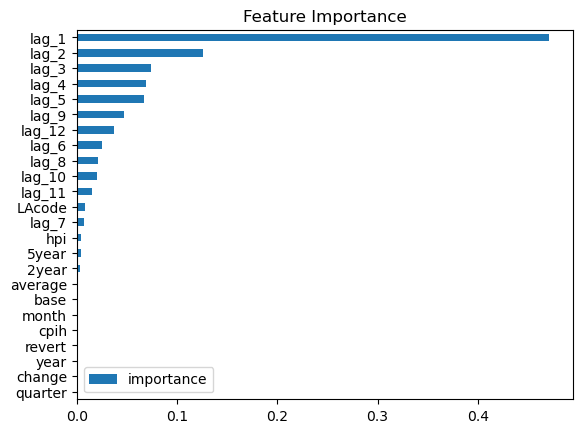

In [9]:
#Visualising feature importance
fi = pd.DataFrame(data=model.feature_importances_,
             index=model.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

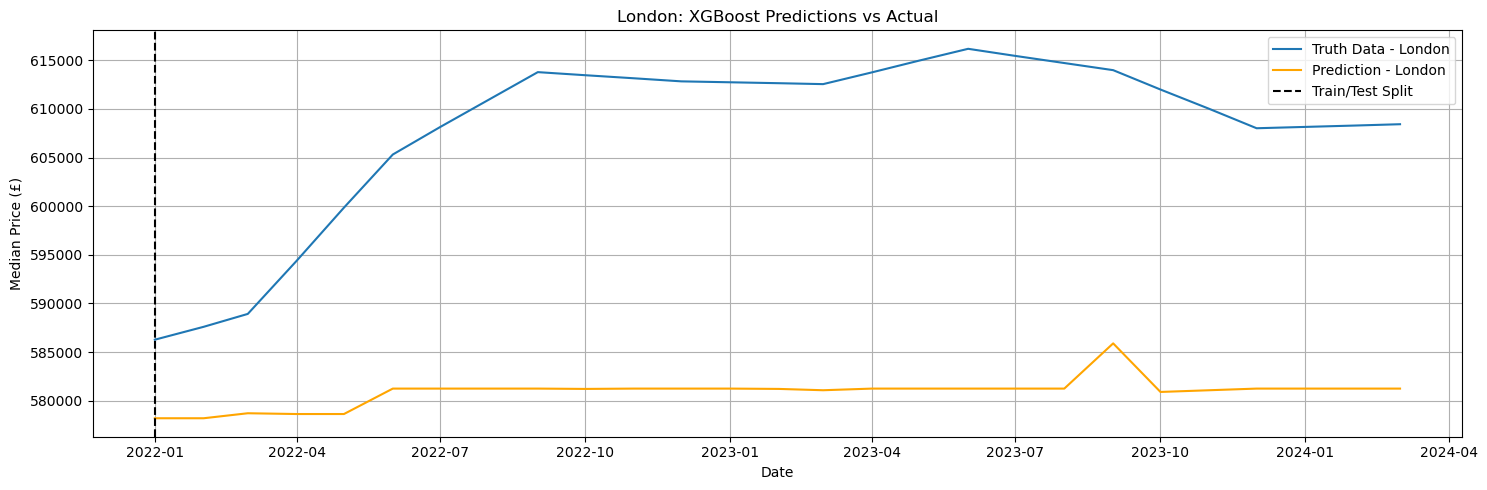

In [10]:
# First, attach predictions to test
test_with_preds = test.copy()
test_with_preds['y_pred'] = y_pred

# Now filter for London
london_test = test_with_preds[test_with_preds['LAcode'] == 7]


plt.figure(figsize=(15, 5))
plt.plot(london_test.index, london_test['median'], label='Truth Data - London')
plt.plot(london_test.index, london_test['y_pred'], label='Prediction - London', color='orange')

plt.axvline(pd.to_datetime('2022-01-01'), color='black', linestyle='--', label='Train/Test Split')

plt.title('London: XGBoost Predictions vs Actual')
plt.xlabel('Date')
plt.ylabel('Median Price (£)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
test_with_preds = test.copy()
test_with_preds['y_pred'] = y_pred

In [12]:
def plot_predictions_by_lacode(lacode, target='median'):
    train_la = train[train['LAcode'] == lacode].copy()
    test_la = test_with_preds[test_with_preds['LAcode'] == lacode].copy()

    # Combine and plot
    full_la = pd.concat([train_la, test_la])

    plt.figure(figsize=(15, 5))
    plt.plot(full_la.index, full_la[target], label='Truth Data', color='steelblue')
    plt.plot(test_la.index, test_la['y_pred'], label='Prediction', color='orange')
    plt.axvline(pd.to_datetime('2022-01-01'), color='black', linestyle='--', label='Train/Test Split')

    plt.title(f'LAcode {lacode}: LASSO Predictions vs Actual')
    plt.xlabel('Date')
    plt.ylabel('Median Price (£)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()




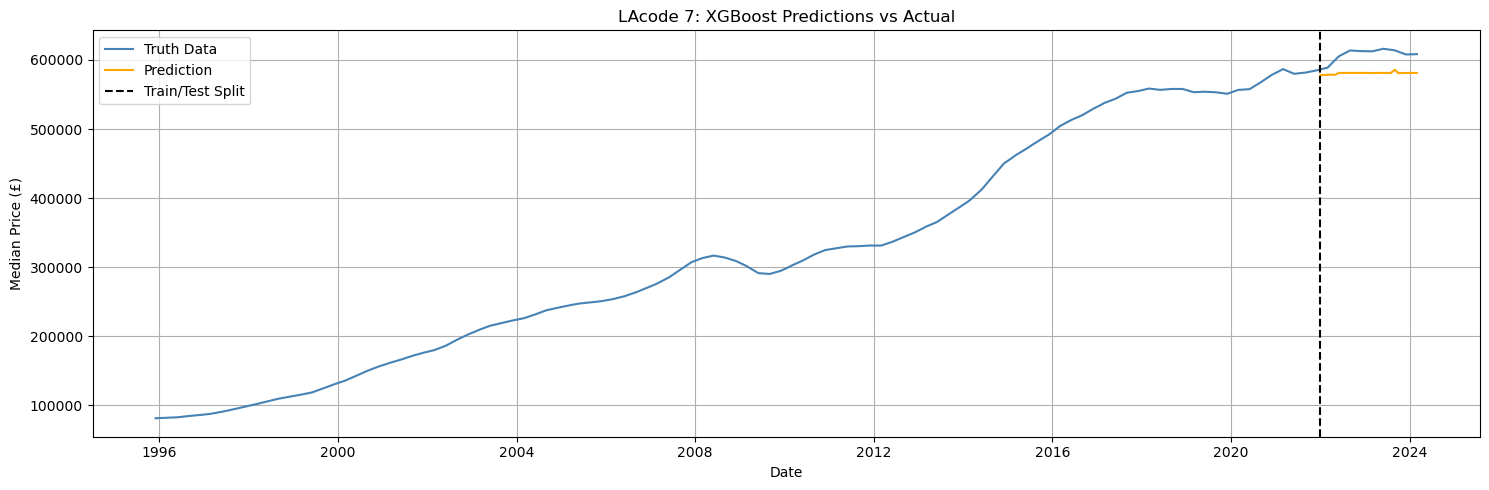

In [13]:
plot_predictions_by_lacode(7)


## Time Based Train/Test Split

## Plotting Predictions for XGBoost with Times Series and Lag Features

## Hyperparameter Tuning

In [14]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [15]:
y_test_pred = best_model.predict(X_test)

# Final prediction measures
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100
r2 = r2_score(y_test, y_test_pred)


print(f'XGBoost RMSE : £{test_rmse:,.2f}')
print(f"XGBoost MAE : {test_mae:.2f}")
print(f"XGBoost MAPE : {test_mape:.2f}%")
print(f"XGBoost r2: {r2:.2f}")

XGBoost RMSE : £24,805.15
XGBoost MAE : 7957.82
XGBoost MAPE : 1.64%
XGBoost r2: 0.98


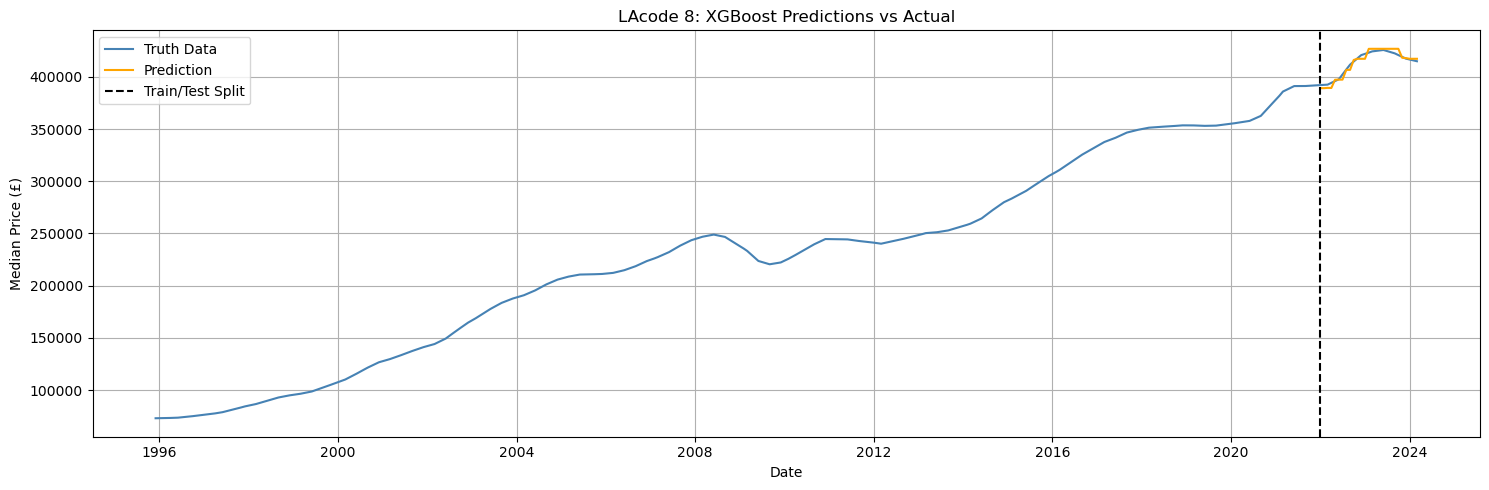

In [16]:
plot_predictions_by_lacode(8)

## Final Model Evaluation 

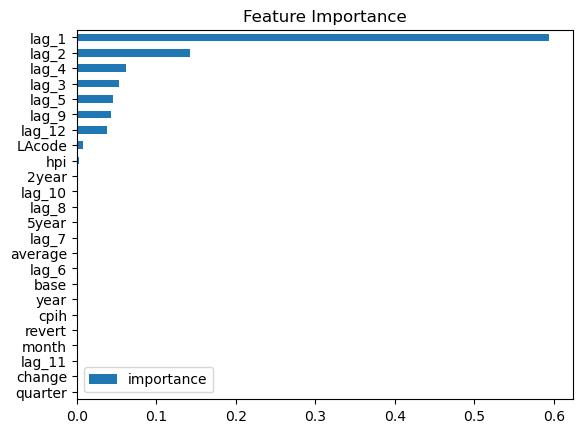

In [17]:
#Visualising feature importance
fi = pd.DataFrame(data=best_model.feature_importances_,
             index=best_model.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

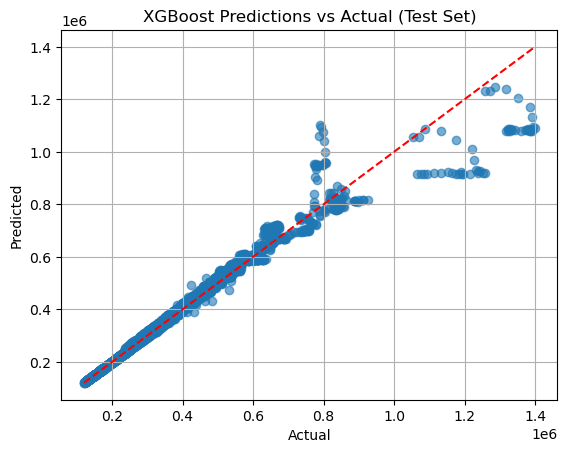

In [20]:
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost Predictions vs Actual (Test Set)")
plt.grid(True)
plt.show()


In [19]:
model_path = "models/xgboost_initial_model.pkl"
joblib.dump(best_model, model_path)

['models/xgboost_initial_model.pkl']